# Signal Detection Eval

This notebook stays thin and delegates all SigMF loading, window selection, spectrogram generation, and annotation overlay drawing to `signal_detection_eval.py`.

Set the capture path and optional window variables below, then run the render cell.

In [33]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

KNOWN_RELATIVE_DIR = Path("applications/usrp_wideband_signal_detection/infocom_evals/signal_detection_experiments")
NOTEBOOK_DIR = (Path.cwd().resolve() / KNOWN_RELATIVE_DIR).resolve()
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import debugging_signal_detection_eval as signal_detection_eval_module

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
DEFAULT_ANNOTATION_INDEX = signal_detection_eval_module.DEFAULT_ANNOTATION_INDEX
DEFAULT_DYNAMIC_RANGE_DB = signal_detection_eval_module.DEFAULT_DYNAMIC_RANGE_DB
DEFAULT_FFT_SIZE = signal_detection_eval_module.DEFAULT_FFT_SIZE
DEFAULT_HOP_SIZE = signal_detection_eval_module.DEFAULT_HOP_SIZE
DEFAULT_INPUT_DATA_PATH = signal_detection_eval_module.DEFAULT_INPUT_DATA_PATH
choose_offline_compatible_window = signal_detection_eval_module.choose_offline_compatible_window
load_sigmf_bundle = signal_detection_eval_module.load_sigmf_bundle
print_sigmf_summary = signal_detection_eval_module.print_sigmf_summary
show_sigmf_spectrogram = signal_detection_eval_module.show_sigmf_spectrogram

print(f"NOTEBOOK_DIR = {NOTEBOOK_DIR}")

NOTEBOOK_DIR = /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/infocom_evals/signal_detection_experiments


In [ ]:
INPUT_DATA_PATH = "/home/bqn82/captures/attenuation_dB_45.sigmf-data"#DEFAULT_INPUT_DATA_PATH

ANNOTATION_INDEX =  557#47 # DEFAULT_ANNOTATION_INDEX
SAMPLE_START = None
SAMPLE_COUNT = None
# #noise region/any arbitrary region
# ANNOTATION_INDEX = None
# SAMPLE_START = 0
# SAMPLE_COUNT = 5242880

FFT_SIZE = DEFAULT_FFT_SIZE
HOP_SIZE = DEFAULT_HOP_SIZE
DYNAMIC_RANGE_DB = DEFAULT_DYNAMIC_RANGE_DB

print(f"INPUT_DATA_PATH = {INPUT_DATA_PATH}")
print(f"ANNOTATION_INDEX = {ANNOTATION_INDEX}  # None picks the largest waveform annotation by default")

INPUT_DATA_PATH = /home/bqn82/captures/attenuation_dB_20.sigmf-data
ANNOTATION_INDEX = 557  # None picks the largest waveform annotation by default


In [35]:
bundle = load_sigmf_bundle(INPUT_DATA_PATH)
window = choose_offline_compatible_window(
    bundle,
    sample_start=SAMPLE_START,
    sample_count=SAMPLE_COUNT,
    annotation_index=ANNOTATION_INDEX,
)
summary = print_sigmf_summary(bundle, window=window)

summary

data_path: /home/bqn82/captures/attenuation_dB_20.sigmf-data
meta_path: /home/bqn82/captures/attenuation_dB_20.sigmf-meta
datatype: cf32_le
sample_rate_hz: 245760000.0
center_frequency_hz: 2000000000.0
capture_sample_start: 0
total_complex_samples: 1754093502
annotation_count: 3594
window_start_sample: 481030873
window_stop_sample: 486273753
window_sample_count: 5242880
window_annotation_index: 557


{'data_path': '/home/bqn82/captures/attenuation_dB_20.sigmf-data',
 'meta_path': '/home/bqn82/captures/attenuation_dB_20.sigmf-meta',
 'datatype': 'cf32_le',
 'sample_rate_hz': 245760000.0,
 'center_frequency_hz': 2000000000.0,
 'capture_sample_start': 0,
 'total_complex_samples': 1754093502,
 'annotation_count': 3594,
 'window_start_sample': 481030873,
 'window_stop_sample': 486273753,
 'window_sample_count': 5242880,
 'window_annotation_index': 557}

Rendered overlays: 4


{'summary': {'data_path': '/home/bqn82/captures/attenuation_dB_20.sigmf-data',
  'meta_path': '/home/bqn82/captures/attenuation_dB_20.sigmf-meta',
  'datatype': 'cf32_le',
  'sample_rate_hz': 245760000.0,
  'center_frequency_hz': 2000000000.0,
  'capture_sample_start': 0,
  'total_complex_samples': 1754093502,
  'annotation_count': 3594,
  'window_start_sample': 481030873,
  'window_stop_sample': 486273753,
  'window_sample_count': 5242880,
  'window_annotation_index': 557},
 'overlay_count': 4,
 'overlays': [{'annotation_index': 554,
   'sample_start': 481194713,
   'sample_stop': 486109913,
   'overlap_start': 481194713,
   'overlap_stop': 486109913,
   'freq_lower_hz': 1928300000.0,
   'freq_upper_hz': 1951700000.0,
   'kind': 'waveform',
   'label': '5G_Downlink'},
  {'annotation_index': 555,
   'sample_start': 481194713,
   'sample_stop': 486109913,
   'overlap_start': 481194713,
   'overlap_stop': 486109913,
   'freq_lower_hz': 1988300000.0,
   'freq_upper_hz': 2011700000.0,
   '

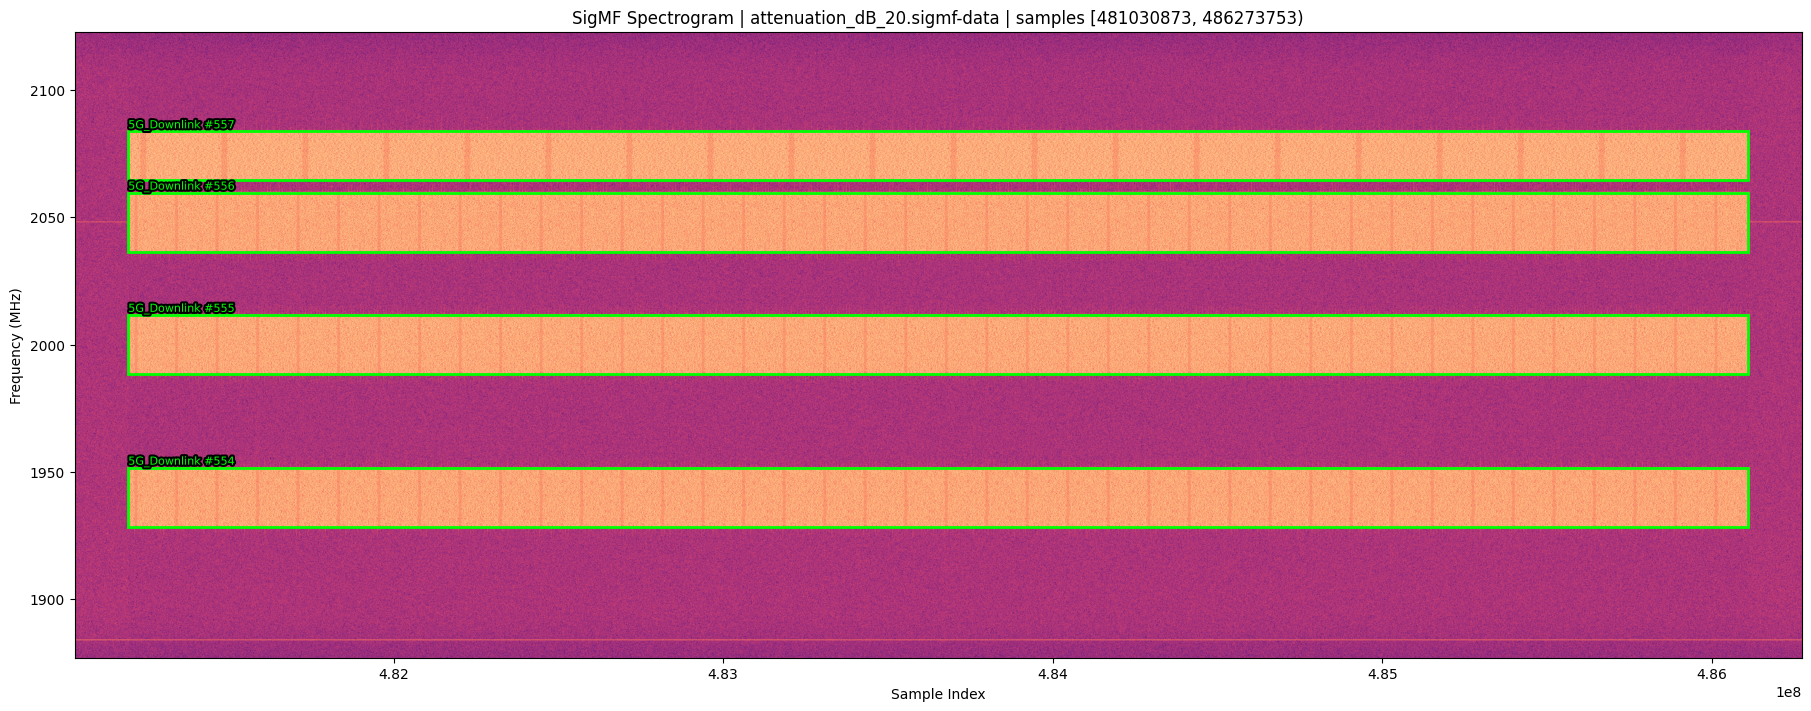

In [36]:
fig, ax, render_context = show_sigmf_spectrogram(
    bundle,
    window=window,
    fft_size=FFT_SIZE,
    hop_size=HOP_SIZE,
    dynamic_range_db=DYNAMIC_RANGE_DB,
)

render_context

## Offline CUDA DINO Run

These cells call the maintained offline application wrapper on the current SigMF input, then load the saved offline artifacts and plot the frame that overlaps the current selected sample window the most.

In [37]:
from pathlib import Path

OFFLINE_CONFIG_PATH = Path("/home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/config_cuda_dino_performance_single_channel.yaml")
#OFFLINE_CONFIG_PATH = Path("/home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/config_coherent_power_performance_single_channel.yaml")
OFFLINE_OUTPUT_ROOT = None
OFFLINE_DRY_RUN = True
OFFLINE_TARGET_CHUNK_COUNT = None
OFFLINE_DEBUG_CHUNK_INDEX = None

print(f"OFFLINE_CONFIG_PATH = {OFFLINE_CONFIG_PATH}")
print(f"OFFLINE_OUTPUT_ROOT = {OFFLINE_OUTPUT_ROOT}")
print(f"OFFLINE_DRY_RUN = {OFFLINE_DRY_RUN}  # leave True to print sudo commands for manual execution")
print(f"OFFLINE_TARGET_CHUNK_COUNT = {OFFLINE_TARGET_CHUNK_COUNT}  # None uses the config default")
print(f"OFFLINE_DEBUG_CHUNK_INDEX = {OFFLINE_DEBUG_CHUNK_INDEX}  # None uses the config default")

OFFLINE_CONFIG_PATH = /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/config_cuda_dino_performance_single_channel.yaml
OFFLINE_OUTPUT_ROOT = None
OFFLINE_DRY_RUN = True  # leave True to print sudo commands for manual execution
OFFLINE_TARGET_CHUNK_COUNT = None  # None uses the config default
OFFLINE_DEBUG_CHUNK_INDEX = None  # None uses the config default


In [38]:
import importlib
import debugging_signal_detection_eval as signal_detection_eval_module

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
find_best_matching_offline_frame = signal_detection_eval_module.find_best_matching_offline_frame
run_offline_detector_file = signal_detection_eval_module.run_offline_detector_file
show_detector_mask_comparison = signal_detection_eval_module.show_detector_mask_comparison

offline_run, offline_output_root = run_offline_detector_file(
    bundle.data_path,
    config_path=OFFLINE_CONFIG_PATH,
    output_root=OFFLINE_OUTPUT_ROOT,
    bundle=bundle,
    window=window,
    target_chunk_count=OFFLINE_TARGET_CHUNK_COUNT,
    debug_chunk_index=OFFLINE_DEBUG_CHUNK_INDEX,
    dry_run=OFFLINE_DRY_RUN,
)

print(offline_run.stdout)
if offline_run.stderr:
    print(offline_run.stderr)

if offline_run.returncode != 0:
    raise RuntimeError(f"Offline detector run helper failed with return code {offline_run.returncode}")

if OFFLINE_DRY_RUN:
    print("Run the printed commands in a terminal, then run the next cell to load and plot the saved artifacts.")

offline_output_root

Preparation commands:
sudo mkdir -p /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_20_samples_481030873_486273753
sudo cp -f /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/generated_inputs/attenuation_dB_20_samples_481030873_486273753.sigmf-data /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_20_samples_481030873_486273753/attenuation_dB_20_samples_481030873_486273753.sigmf-data
sudo cp -f /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/generated_inputs/attenuation_dB_20_samples_481030873_486273753.sigmf-meta /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_20_samples_481030873_486273753/attenuation_dB_20_samples_481030873_486273753.sigmf-meta
sudo mkdir -p /tmp/usrp_spectrograms/offline_cuda_dino
Offline CUDA DINO command:
sudo docker exec -i usrp_x410_signal_detection_demo bash -lc '/workspace/holohub/build/usrp_wideband_signal_detection/applications/usrp_wideband_signal_detection/run_offline_cuda_detector_eval --config /wor

PosixPath('/tmp/usrp_spectrograms/offline_cuda_dino/attenuation_dB_20_samples_481030873_486273753')

In [39]:
import importlib

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
load_offline_saved_masks = signal_detection_eval_module.load_offline_saved_masks
show_offline_saved_mask_comparison = signal_detection_eval_module.show_offline_saved_mask_comparison
show_offline_saved_binary_masks = signal_detection_eval_module.show_offline_saved_binary_masks

offline_saved_masks = load_offline_saved_masks(
    offline_output_root,
    window=window,
    bundle=bundle,
 )
saved_gt_mask = offline_saved_masks.ground_truth_mask
saved_detector_mask = offline_saved_masks.detector_mask
fig_compare, axes_compare, compare_context = show_offline_saved_mask_comparison(
    bundle,
    window,
    saved_detector_mask=saved_detector_mask,
    saved_gt_mask=saved_gt_mask,
    fft_size=FFT_SIZE,
    hop_size=HOP_SIZE,
    dynamic_range_db=DYNAMIC_RANGE_DB,
)
fig_binary_masks, axes_binary_masks, binary_mask_context = show_offline_saved_binary_masks(
    bundle,
    window,
    saved_detector_mask=saved_detector_mask,
    saved_gt_mask=saved_gt_mask,
)

compare_context = {
    **compare_context,
    **offline_saved_masks.context,
    "detector_type": offline_saved_masks.detector_type,
    "binary_masks": binary_mask_context,
}

compare_context

FileNotFoundError: No supported offline artifact summary was found under /tmp/usrp_spectrograms/offline_cuda_dino/attenuation_dB_20_samples_481030873_486273753

In [ ]:
import importlib

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
load_offline_detector_debug_artifacts = signal_detection_eval_module.load_offline_detector_debug_artifacts
show_offline_detector_debug_pathways = signal_detection_eval_module.show_offline_detector_debug_pathways
show_offline_detector_debug_postprocess = signal_detection_eval_module.show_offline_detector_debug_postprocess

debug_artifacts = load_offline_detector_debug_artifacts(offline_output_root)
fig_debug_pathways, axes_debug_pathways, debug_pathway_context = show_offline_detector_debug_pathways(
    debug_artifacts,
 )
fig_debug_postprocess, axes_debug_postprocess, debug_postprocess_context = show_offline_detector_debug_postprocess(
    debug_artifacts,
    saved_detector_mask=saved_detector_mask,
    saved_gt_mask=saved_gt_mask,
 )

debug_context = {
    "pathways": debug_pathway_context,
    "postprocess": debug_postprocess_context,
}

debug_context

In [ ]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)

if debug_artifacts.detector_type != "coherent_power":
    raise ValueError("This diagnostic cell is intended for coherent_power debug artifacts.")

corrected_full = np.asarray(debug_artifacts.chunk_arrays["corrected_full_npy"], dtype=np.float32)
corrected_chunk = np.asarray(debug_artifacts.chunk_arrays["corrected_chunk_npy"], dtype=np.float32)
corrected_resized = np.asarray(debug_artifacts.chunk_arrays["corrected_resized_npy"], dtype=np.float32)

selected_chunk_index = int(debug_artifacts.validation_summary.get("selected_chunk_index", 0) or 0)
selected_chunk_row_start = int(debug_artifacts.validation_summary.get("selected_chunk_row_start", 0) or 0)
selected_chunk_row_stop = int(
    debug_artifacts.validation_summary.get("selected_chunk_row_stop", corrected_full.shape[0]) or corrected_full.shape[0]
 )
chunk_count = int(debug_artifacts.validation_summary.get("chunk_count", 1) or 1)

full_row_mean = corrected_full.mean(axis=1)
full_row_std = corrected_full.std(axis=1)

fig_corrected_origin, axes_corrected_origin = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

image_panels = [
    (axes_corrected_origin[0, 0], corrected_full, f"Full Corrected Grid {tuple(corrected_full.shape)}", "magma"),
    (axes_corrected_origin[0, 1], corrected_chunk, f"Selected Chunk {selected_chunk_index} rows {selected_chunk_row_start}:{selected_chunk_row_stop} {tuple(corrected_chunk.shape)}", "magma"),
    (axes_corrected_origin[1, 0], corrected_resized, f"Selected Chunk Resized {tuple(corrected_resized.shape)}", "magma"),
]

for ax, image, title, cmap in image_panels:
    finite = np.asarray(image, dtype=np.float32)
    vmin, vmax = np.percentile(finite, [5.0, 99.5]) if finite.size else (0.0, 1.0)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin, vmax = float(np.nanmin(finite)), float(np.nanmax(finite))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
            vmin, vmax = 0.0, 1.0
    ax.imshow(finite, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Time bins")
    ax.set_ylabel("Frequency bins")

profile_ax = axes_corrected_origin[1, 1]
profile_ax.plot(full_row_mean, np.arange(full_row_mean.size), label="row mean")
profile_ax.plot(full_row_mean + full_row_std, np.arange(full_row_mean.size), alpha=0.35, label="row mean + std")
profile_ax.axhspan(selected_chunk_row_start, selected_chunk_row_stop, color="tab:red", alpha=0.18, label="selected chunk")
profile_ax.set_title(f"Full-grid row profile, chunk_count={chunk_count}")
profile_ax.set_xlabel("Power dB")
profile_ax.set_ylabel("Frequency row")
profile_ax.legend(loc="best")

corrected_origin_context = {
    "detector_type": debug_artifacts.detector_type,
    "chunk_count": chunk_count,
    "selected_chunk_index": selected_chunk_index,
    "selected_chunk_row_start": selected_chunk_row_start,
    "selected_chunk_row_stop": selected_chunk_row_stop,
    "corrected_full_shape": tuple(int(v) for v in corrected_full.shape),
    "corrected_chunk_shape": tuple(int(v) for v in corrected_chunk.shape),
    "corrected_resized_shape": tuple(int(v) for v in corrected_resized.shape),
}

corrected_origin_context